# FungAI: Microscopic Fungi Classification with CNNs
**Bernandino, Ganayo, Punsalan, Tandingan**

This notebook implements the full experimental plan from the FungAI proposal:

1. Load & split the DeFungi dataset (stratified 70/15/15, seed=42)
2. Baseline CNN trained from scratch
3. ResNet50 and EfficientNet-B0 (frozen vs. fine-tuned)
4. Class-weighted cross-entropy for imbalance (6:1 ratio)
5. Geometric-only augmentation
6. Three ablations: augmentation on/off, frozen vs. fine-tuned, weighted vs. unweighted loss
7. Metrics: accuracy, macro P/R/F1, confusion matrices
8. Grad-CAM visualizations

**Run this on Google Colab with a T4 GPU** (Runtime → Change runtime type → GPU).


## 0. Setup Proper

In [5]:
# Install/confirm dependencies (Colab already has torch/torchvision)
!pip install -q grad-cam scikit-learn seaborn


In [6]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("joebeachcapital/defungi")
print(path)

100%|██████████| 149M/149M [00:01<00:00, 104MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/joebeachcapital/defungi/versions/1


In [7]:
import os, random, time, copy, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Explicit fast mode: let cuDNN auto-tune and cache the fastest conv algorithm
# for our fixed 224x224 / batch-32 shape, instead of the slower bit-exact kernels.
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False


Device: cuda


## 1. Data loading & stratified split

DeFungi has 5 classes (folder names typically `H1,H2,H3,H5,H6` in the raw release, or class
codes like `TSH`/`BBH` etc. as referenced in the proposal). Adjust `DATA_DIR` and `CLASS_NAMES`
to match whatever folder layout you download. The loader below just needs an `ImageFolder`-style
directory: `DATA_DIR/<class_name>/<image>.jpg`.


In [8]:
DATA_DIR = path
IMG_SIZE = 224

# torchvision ImageFolder gives us (path, label) pairs; we then do our own stratified split
full_dataset = ImageFolder(DATA_DIR)
CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Total images:", len(full_dataset))

targets = np.array([s[1] for s in full_dataset.samples])
indices = np.arange(len(full_dataset))

# 70/15/15 stratified split, fixed seed
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=targets, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, stratify=targets[temp_idx], random_state=SEED)

print(f"Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}")

# class counts / imbalance check
counts = pd.Series(targets).value_counts().sort_index()
counts.index = CLASS_NAMES
print(counts)
class_weights_raw = 1.0 / counts.values
class_weights = class_weights_raw / class_weights_raw.sum() * NUM_CLASSES
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASS_NAMES, class_weights.round(3))))


Classes: ['H1', 'H2', 'H3', 'H5', 'H6']
Total images: 9114
Train: 6379  Val: 1367  Test: 1368
H1    4404
H2    2334
H3     819
H5     818
H6     739
Name: count, dtype: int64
Class weights: {'H1': np.float64(0.255), 'H2': np.float64(0.481), 'H3': np.float64(1.371), 'H5': np.float64(1.373), 'H6': np.float64(1.52)}


## 2. Transforms (geometric-only augmentation) & Dataset wrapper

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

geometric_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(20),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

no_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = no_aug  # val/test never augmented

class TransformSubset(Dataset):
    """Wrap ImageFolder + an index list with a chosen transform."""
    def __init__(self, base_dataset, idx_list, transform):
        self.base = base_dataset
        self.idx_list = idx_list
        self.transform = transform

    def __len__(self):
        return len(self.idx_list)

    def __getitem__(self, i):
        path, label = self.base.samples[self.idx_list[i]]
        img = self.base.loader(path)
        img = self.transform(img)
        return img, label

def make_loaders(train_transform, batch_size=32):
    train_ds = TransformSubset(full_dataset, train_idx, train_transform)
    val_ds   = TransformSubset(full_dataset, val_idx, eval_tf)
    test_ds  = TransformSubset(full_dataset, test_idx, eval_tf)
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_ld   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_ld  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_ld, val_ld, test_ld


## 3. Baseline CNN (trained from scratch)

In [10]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            )
        self.features = nn.Sequential(
            block(3, 32),
            block(32, 64),
            block(64, 128),
            block(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


## 4. Pretrained backbones (ResNet50, EfficientNet-B0) — frozen / fine-tuned

In [11]:
def build_resnet50(num_classes=5, finetune=False):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for p in m.parameters():
        p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    if finetune:
        for p in m.layer4.parameters():   # last conv block
            p.requires_grad = True
    return m

def build_efficientnet_b0(num_classes=5, finetune=False):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in m.parameters():
        p.requires_grad = False
    in_f = m.classifier[1].in_features
    m.classifier = nn.Sequential(nn.Dropout(0.2), nn.Linear(in_f, num_classes))
    if finetune:
        for p in m.features[-1].parameters():   # final MBConv block
            p.requires_grad = True
    return m

def get_param_groups(model, finetune, head_lr=1e-3, backbone_lr=1e-4):
    """Head always trains at head_lr; unfrozen backbone layers train ~10x slower."""
    head_params, backbone_params = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if any(k in n for k in ["fc", "classifier"]):
            head_params.append(p)
        else:
            backbone_params.append(p)
    groups = [{"params": head_params, "lr": head_lr}]
    if finetune and backbone_params:
        groups.append({"params": backbone_params, "lr": backbone_lr})
    return groups


## 5. Generic training loop (Adam, early stopping, optional class weights)

In [12]:
def train_model(model, train_loader, val_loader, class_weights=None,
                 lr=1e-3, param_groups=None, epochs=30, patience=5, tag="model"):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    if param_groups is not None:
        optimizer = optim.Adam(param_groups)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        t0 = time.time()
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labels)
                val_loss += loss.item() * imgs.size(0)
                preds = out.argmax(1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_loss /= len(val_loader.dataset)
        val_acc = correct / total
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"[{tag}] epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
              f"({time.time()-t0:.1f}s)")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{tag}] early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model, history


## 6. Evaluation (accuracy, macro P/R/F1, confusion matrix)

In [13]:
def evaluate_model(model, loader, tag="model", plot_cm=True):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="macro", zero_division=0)
    print(f"[{tag}] test_acc={acc:.4f}  macro_P={prec:.4f}  macro_R={rec:.4f}  macro_F1={f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    if plot_cm:
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f"Confusion Matrix — {tag}")
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(f"cm_{tag}.png", dpi=150)
        plt.show()

    return {"tag": tag, "accuracy": acc, "macro_precision": prec, "macro_recall": rec,
            "macro_f1": f1, "confusion_matrix": cm.tolist()}


## 7. Run experiments

Each call trains one configuration. Results are collected into `results_log` (a list of dicts)
so you can dump a single results table at the end for your slides/paper.


[baseline_cnn] epoch 1/30 train_loss=1.0781 val_loss=0.9546 val_acc=0.6189 (61.6s)
[baseline_cnn] epoch 2/30 train_loss=0.9881 val_loss=0.9340 val_acc=0.6416 (44.4s)
[baseline_cnn] epoch 3/30 train_loss=0.9555 val_loss=0.9351 val_acc=0.5772 (47.9s)
[baseline_cnn] epoch 4/30 train_loss=0.9339 val_loss=0.8880 val_acc=0.6562 (44.7s)
[baseline_cnn] epoch 5/30 train_loss=0.9109 val_loss=0.9038 val_acc=0.5574 (44.8s)
[baseline_cnn] epoch 6/30 train_loss=0.9005 val_loss=0.8595 val_acc=0.6357 (46.1s)
[baseline_cnn] epoch 7/30 train_loss=0.8803 val_loss=0.8972 val_acc=0.6437 (45.1s)
[baseline_cnn] epoch 8/30 train_loss=0.8875 val_loss=0.8904 val_acc=0.6723 (56.8s)
[baseline_cnn] epoch 9/30 train_loss=0.8502 val_loss=0.8772 val_acc=0.6730 (44.9s)
[baseline_cnn] epoch 10/30 train_loss=0.8454 val_loss=0.8991 val_acc=0.6650 (45.6s)
[baseline_cnn] epoch 11/30 train_loss=0.8483 val_loss=0.8386 val_acc=0.6598 (46.4s)
[baseline_cnn] epoch 12/30 train_loss=0.8534 val_loss=0.8465 val_acc=0.6320 (46.4s)
[

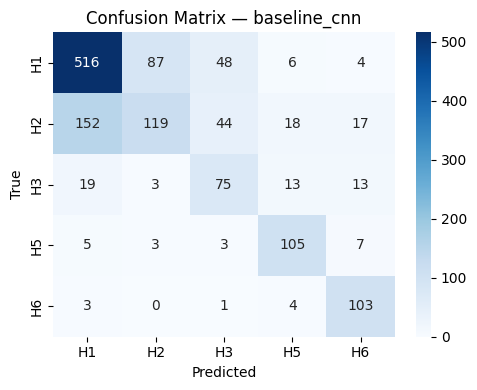

In [14]:
trained_models = {}   # every trained model, used by the deferred Grad-CAM pass below

results_log = []

train_loader_aug, val_loader, test_loader = make_loaders(geometric_aug, batch_size=32)

# --- Baseline CNN, weighted loss, augmentation ON (main config) ---
baseline = BaselineCNN(NUM_CLASSES)
baseline, hist_baseline = train_model(
    baseline, train_loader_aug, val_loader,
    class_weights=class_weights_tensor, lr=1e-3, epochs=30, patience=5, tag="baseline_cnn"
)
res = evaluate_model(baseline, test_loader, tag="baseline_cnn")
res["config"] = {"model": "BaselineCNN", "augmentation": True, "weighted_loss": True, "finetune": "n/a"}
results_log.append(res)
trained_models["baseline_cnn"] = baseline


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s]


[resnet50_frozen] epoch 1/30 train_loss=1.1039 val_loss=0.9536 val_acc=0.6152 (63.0s)
[resnet50_frozen] epoch 2/30 train_loss=0.8747 val_loss=0.8398 val_acc=0.6533 (48.2s)
[resnet50_frozen] epoch 3/30 train_loss=0.8023 val_loss=0.7972 val_acc=0.6737 (48.9s)
[resnet50_frozen] epoch 4/30 train_loss=0.7483 val_loss=0.7873 val_acc=0.6752 (49.3s)
[resnet50_frozen] epoch 5/30 train_loss=0.7283 val_loss=0.7466 val_acc=0.6928 (48.8s)
[resnet50_frozen] epoch 6/30 train_loss=0.7163 val_loss=0.7256 val_acc=0.7191 (49.4s)
[resnet50_frozen] epoch 7/30 train_loss=0.7139 val_loss=0.7056 val_acc=0.6884 (48.0s)
[resnet50_frozen] epoch 8/30 train_loss=0.6874 val_loss=0.6926 val_acc=0.7096 (49.1s)
[resnet50_frozen] epoch 9/30 train_loss=0.6638 val_loss=0.6994 val_acc=0.7330 (49.1s)
[resnet50_frozen] epoch 10/30 train_loss=0.6630 val_loss=0.6944 val_acc=0.7162 (48.1s)
[resnet50_frozen] epoch 11/30 train_loss=0.6540 val_loss=0.6803 val_acc=0.7169 (50.0s)
[resnet50_frozen] epoch 12/30 train_loss=0.6525 val_

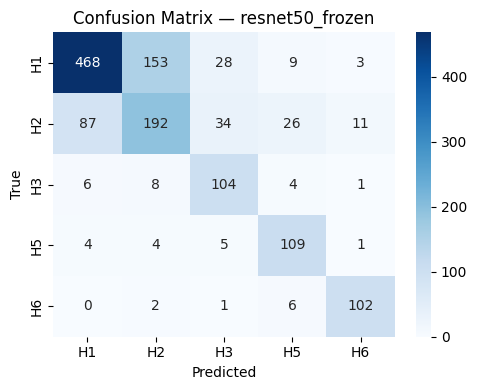

[resnet50_finetuned] epoch 1/30 train_loss=0.8670 val_loss=0.6249 val_acc=0.6818 (52.7s)
[resnet50_finetuned] epoch 2/30 train_loss=0.5883 val_loss=0.5380 val_acc=0.6430 (49.8s)
[resnet50_finetuned] epoch 3/30 train_loss=0.4919 val_loss=0.5099 val_acc=0.7981 (50.1s)
[resnet50_finetuned] epoch 4/30 train_loss=0.4343 val_loss=0.4040 val_acc=0.8347 (50.8s)
[resnet50_finetuned] epoch 5/30 train_loss=0.4009 val_loss=0.3759 val_acc=0.8398 (50.6s)
[resnet50_finetuned] epoch 6/30 train_loss=0.3530 val_loss=0.3606 val_acc=0.8508 (49.8s)
[resnet50_finetuned] epoch 7/30 train_loss=0.3178 val_loss=0.3393 val_acc=0.8259 (50.0s)
[resnet50_finetuned] epoch 8/30 train_loss=0.3036 val_loss=0.3282 val_acc=0.8574 (50.1s)
[resnet50_finetuned] epoch 9/30 train_loss=0.2774 val_loss=0.3426 val_acc=0.8632 (49.8s)
[resnet50_finetuned] epoch 10/30 train_loss=0.2543 val_loss=0.3367 val_acc=0.8625 (48.6s)
[resnet50_finetuned] epoch 11/30 train_loss=0.2356 val_loss=0.3354 val_acc=0.8522 (49.8s)
[resnet50_finetuned

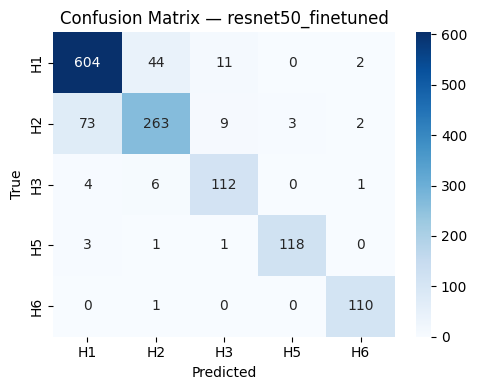

In [15]:
# --- ResNet50: frozen and fine-tuned ---
for finetune in [False, True]:
    tag = f"resnet50_{'finetuned' if finetune else 'frozen'}"
    model = build_resnet50(NUM_CLASSES, finetune=finetune)
    groups = get_param_groups(model, finetune, head_lr=1e-3, backbone_lr=1e-4)
    model, hist = train_model(model, train_loader_aug, val_loader,
                               class_weights=class_weights_tensor,
                               param_groups=groups, epochs=30, patience=5, tag=tag)
    res = evaluate_model(model, test_loader, tag=tag)
    res["config"] = {"model": "ResNet50", "augmentation": True, "weighted_loss": True, "finetune": finetune}
    results_log.append(res)
    trained_models[tag] = model


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 


[effnetb0_frozen] epoch 1/30 train_loss=1.1375 val_loss=0.9697 val_acc=0.6108 (42.4s)
[effnetb0_frozen] epoch 2/30 train_loss=0.9290 val_loss=0.8682 val_acc=0.6832 (42.0s)
[effnetb0_frozen] epoch 3/30 train_loss=0.8701 val_loss=0.8220 val_acc=0.6664 (43.2s)
[effnetb0_frozen] epoch 4/30 train_loss=0.8500 val_loss=0.7953 val_acc=0.6840 (44.6s)
[effnetb0_frozen] epoch 5/30 train_loss=0.8253 val_loss=0.7667 val_acc=0.6803 (44.8s)
[effnetb0_frozen] epoch 6/30 train_loss=0.8126 val_loss=0.7609 val_acc=0.6825 (43.7s)
[effnetb0_frozen] epoch 7/30 train_loss=0.7822 val_loss=0.7358 val_acc=0.7096 (49.0s)
[effnetb0_frozen] epoch 8/30 train_loss=0.8066 val_loss=0.7588 val_acc=0.6554 (43.4s)
[effnetb0_frozen] epoch 9/30 train_loss=0.7746 val_loss=0.7534 val_acc=0.6642 (44.0s)
[effnetb0_frozen] epoch 10/30 train_loss=0.7786 val_loss=0.7256 val_acc=0.6869 (44.8s)
[effnetb0_frozen] epoch 11/30 train_loss=0.7763 val_loss=0.7442 val_acc=0.6474 (43.5s)
[effnetb0_frozen] epoch 12/30 train_loss=0.7606 val_

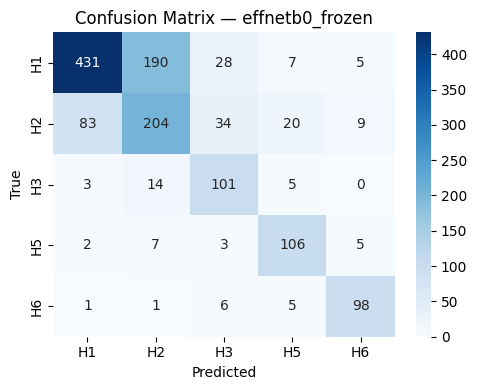

[effnetb0_finetuned] epoch 1/30 train_loss=1.0673 val_loss=0.9276 val_acc=0.6225 (42.2s)
[effnetb0_finetuned] epoch 2/30 train_loss=0.8507 val_loss=0.8271 val_acc=0.6496 (42.5s)
[effnetb0_finetuned] epoch 3/30 train_loss=0.7959 val_loss=0.7577 val_acc=0.6752 (42.4s)
[effnetb0_finetuned] epoch 4/30 train_loss=0.7394 val_loss=0.7324 val_acc=0.6862 (43.5s)
[effnetb0_finetuned] epoch 5/30 train_loss=0.7265 val_loss=0.6939 val_acc=0.6825 (42.3s)
[effnetb0_finetuned] epoch 6/30 train_loss=0.6865 val_loss=0.6499 val_acc=0.7074 (43.6s)
[effnetb0_finetuned] epoch 7/30 train_loss=0.6795 val_loss=0.6458 val_acc=0.7198 (43.6s)
[effnetb0_finetuned] epoch 8/30 train_loss=0.6685 val_loss=0.6609 val_acc=0.7052 (43.8s)
[effnetb0_finetuned] epoch 9/30 train_loss=0.6294 val_loss=0.5968 val_acc=0.7228 (44.6s)
[effnetb0_finetuned] epoch 10/30 train_loss=0.6379 val_loss=0.6109 val_acc=0.6964 (43.1s)
[effnetb0_finetuned] epoch 11/30 train_loss=0.6248 val_loss=0.6022 val_acc=0.6964 (43.0s)
[effnetb0_finetuned

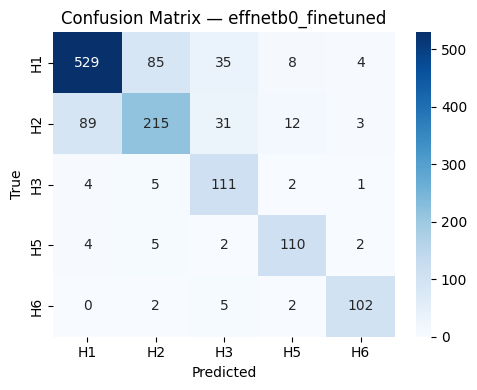

In [16]:
# --- EfficientNet-B0: frozen and fine-tuned ---
for finetune in [False, True]:
    tag = f"effnetb0_{'finetuned' if finetune else 'frozen'}"
    model = build_efficientnet_b0(NUM_CLASSES, finetune=finetune)
    groups = get_param_groups(model, finetune, head_lr=1e-3, backbone_lr=1e-4)
    model, hist = train_model(model, train_loader_aug, val_loader,
                               class_weights=class_weights_tensor,
                               param_groups=groups, epochs=30, patience=5, tag=tag)
    res = evaluate_model(model, test_loader, tag=tag)
    res["config"] = {"model": "EfficientNet-B0", "augmentation": True, "weighted_loss": True, "finetune": finetune}
    results_log.append(res)
    trained_models[tag] = model


## 8. Ablations

Each ablation changes exactly **one** factor relative to the best main-config model
(pick whichever of the three models above performed best to run these on, or run
across all three if time allows — the loop below defaults to the baseline CNN and
the fine-tuned ResNet50 as an example).


[ablation_no_augmentation] epoch 1/30 train_loss=1.0659 val_loss=0.9697 val_acc=0.6481 (36.2s)
[ablation_no_augmentation] epoch 2/30 train_loss=0.9599 val_loss=0.9247 val_acc=0.5684 (36.2s)
[ablation_no_augmentation] epoch 3/30 train_loss=0.9398 val_loss=0.9162 val_acc=0.6203 (35.0s)
[ablation_no_augmentation] epoch 4/30 train_loss=0.9085 val_loss=0.8720 val_acc=0.6086 (35.7s)
[ablation_no_augmentation] epoch 5/30 train_loss=0.8912 val_loss=0.9741 val_acc=0.5084 (36.2s)
[ablation_no_augmentation] epoch 6/30 train_loss=0.8586 val_loss=0.8906 val_acc=0.6518 (35.2s)
[ablation_no_augmentation] epoch 7/30 train_loss=0.8481 val_loss=0.8699 val_acc=0.6920 (35.5s)
[ablation_no_augmentation] epoch 8/30 train_loss=0.8368 val_loss=0.8283 val_acc=0.6459 (36.1s)
[ablation_no_augmentation] epoch 9/30 train_loss=0.8260 val_loss=0.8527 val_acc=0.6803 (34.5s)
[ablation_no_augmentation] epoch 10/30 train_loss=0.8098 val_loss=0.8385 val_acc=0.6913 (35.7s)
[ablation_no_augmentation] epoch 11/30 train_loss

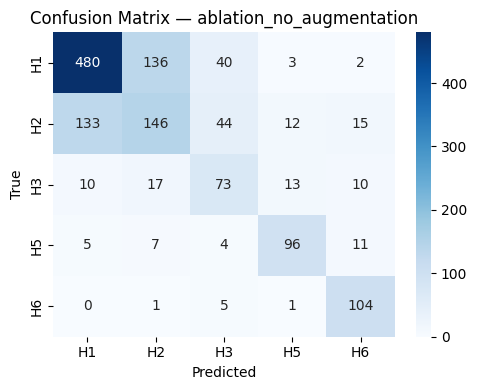

In [17]:
# Ablation A: augmentation ON vs OFF (baseline CNN)
train_loader_noaug, _, _ = make_loaders(no_aug, batch_size=32)

model_noaug = BaselineCNN(NUM_CLASSES)
model_noaug, _ = train_model(model_noaug, train_loader_noaug, val_loader,
                              class_weights=class_weights_tensor, lr=1e-3,
                              epochs=30, patience=5, tag="ablation_no_augmentation")
res = evaluate_model(model_noaug, test_loader, tag="ablation_no_augmentation")
res["config"] = {"model": "BaselineCNN", "augmentation": False, "weighted_loss": True, "finetune": "n/a"}
results_log.append(res)


[ablation_unweighted_loss] epoch 1/30 train_loss=0.9544 val_loss=0.8912 val_acc=0.6364 (45.1s)
[ablation_unweighted_loss] epoch 2/30 train_loss=0.8845 val_loss=0.8499 val_acc=0.6496 (44.2s)
[ablation_unweighted_loss] epoch 3/30 train_loss=0.8659 val_loss=0.8728 val_acc=0.6203 (43.9s)
[ablation_unweighted_loss] epoch 4/30 train_loss=0.8614 val_loss=0.8302 val_acc=0.6591 (45.5s)
[ablation_unweighted_loss] epoch 5/30 train_loss=0.8460 val_loss=0.8419 val_acc=0.6613 (43.8s)
[ablation_unweighted_loss] epoch 6/30 train_loss=0.8323 val_loss=0.8430 val_acc=0.6715 (44.3s)
[ablation_unweighted_loss] epoch 7/30 train_loss=0.8323 val_loss=0.7915 val_acc=0.6811 (45.0s)
[ablation_unweighted_loss] epoch 8/30 train_loss=0.8304 val_loss=0.8025 val_acc=0.6796 (43.4s)
[ablation_unweighted_loss] epoch 9/30 train_loss=0.8042 val_loss=0.7869 val_acc=0.6818 (44.2s)
[ablation_unweighted_loss] epoch 10/30 train_loss=0.8004 val_loss=0.7722 val_acc=0.6928 (43.6s)
[ablation_unweighted_loss] epoch 11/30 train_loss

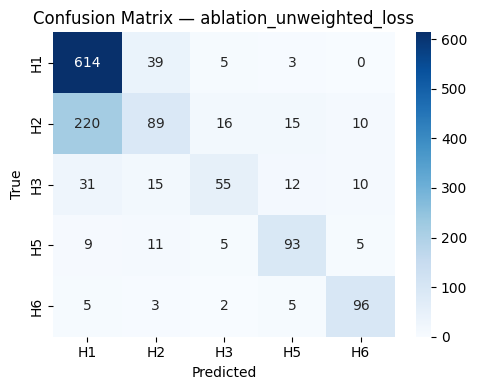

In [18]:
# Ablation B: weighted vs unweighted loss (baseline CNN)
model_unweighted = BaselineCNN(NUM_CLASSES)
model_unweighted, _ = train_model(model_unweighted, train_loader_aug, val_loader,
                                   class_weights=None, lr=1e-3,
                                   epochs=30, patience=5, tag="ablation_unweighted_loss")
res = evaluate_model(model_unweighted, test_loader, tag="ablation_unweighted_loss")
res["config"] = {"model": "BaselineCNN", "augmentation": True, "weighted_loss": False, "finetune": "n/a"}
results_log.append(res)


In [19]:
# Ablation C: frozen vs fine-tuned is already covered by the ResNet50 / EfficientNet-B0
# loops above (both configurations were trained and logged). No extra run needed —
# just compare the *_frozen vs *_finetuned rows in results_log.
print("Frozen-vs-finetuned ablation already captured in results_log:")
for r in results_log:
    if "resnet50" in r["tag"] or "effnetb0" in r["tag"]:
        print(r["tag"], "-> macro_f1:", round(r["macro_f1"], 4))


Frozen-vs-finetuned ablation already captured in results_log:
resnet50_frozen -> macro_f1: 0.7376
resnet50_finetuned -> macro_f1: 0.901
effnetb0_frozen -> macro_f1: 0.7208
effnetb0_finetuned -> macro_f1: 0.7931


## Statistical significance (fills Table 6)

Repeats the 5 main configurations across multiple seeds so the paper can report mean ± std macro-F1 instead of a single point estimate. This is real additional training time -- 5 configs × 3 seeds = 15 more runs on top of everything above. If you're short on time, cut `SEEDS` down to 2, or drop to just the configs whose claims matter most (e.g. `resnet50_finetuned` vs `baseline_cnn`, since that's the headline 0.274 gap the paper leans on).

In [20]:
SEEDS = [42, 123]

def build_and_train(cfg_name, seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if cfg_name == "baseline_cnn":
        model = BaselineCNN(NUM_CLASSES)
        model, _ = train_model(model, train_loader_aug, val_loader,
                                class_weights=class_weights_tensor, lr=1e-3,
                                epochs=30, patience=5, tag=f"{cfg_name}_seed{seed}")
    elif cfg_name in ("resnet50_frozen", "resnet50_finetuned"):
        finetune = cfg_name.endswith("finetuned")
        model = build_resnet50(NUM_CLASSES, finetune=finetune)
        groups = get_param_groups(model, finetune, head_lr=1e-3, backbone_lr=1e-4)
        model, _ = train_model(model, train_loader_aug, val_loader,
                                class_weights=class_weights_tensor, param_groups=groups,
                                epochs=30, patience=5, tag=f"{cfg_name}_seed{seed}")
    elif cfg_name in ("effnetb0_frozen", "effnetb0_finetuned"):
        finetune = cfg_name.endswith("finetuned")
        model = build_efficientnet_b0(NUM_CLASSES, finetune=finetune)
        groups = get_param_groups(model, finetune, head_lr=1e-3, backbone_lr=1e-4)
        model, _ = train_model(model, train_loader_aug, val_loader,
                                class_weights=class_weights_tensor, param_groups=groups,
                                epochs=30, patience=5, tag=f"{cfg_name}_seed{seed}")
    else:
        raise ValueError(cfg_name)

    res = evaluate_model(model, test_loader, tag=f"{cfg_name}_seed{seed}", plot_cm=False)
    return res["macro_f1"]

CONFIGS = ["baseline_cnn", "resnet50_frozen", "resnet50_finetuned",
           "effnetb0_frozen", "effnetb0_finetuned"]

multi_seed_f1 = {cfg: [] for cfg in CONFIGS}

for cfg in CONFIGS:
    for seed in SEEDS:
        f1 = build_and_train(cfg, seed)
        multi_seed_f1[cfg].append(f1)

print(f"{'Configuration':<22} macro F1 (mean ± std)")
for cfg in CONFIGS:
    vals = multi_seed_f1[cfg]
    print(f"{cfg:<22} {np.mean(vals):.4f} ± {np.std(vals):.4f}   (per-seed: {[round(v,4) for v in vals]})")


[baseline_cnn_seed42] epoch 1/30 train_loss=1.0784 val_loss=0.9532 val_acc=0.6159 (44.4s)
[baseline_cnn_seed42] epoch 2/30 train_loss=0.9867 val_loss=0.9294 val_acc=0.6394 (43.7s)
[baseline_cnn_seed42] epoch 3/30 train_loss=0.9514 val_loss=0.9215 val_acc=0.5764 (43.7s)
[baseline_cnn_seed42] epoch 4/30 train_loss=0.9317 val_loss=0.8877 val_acc=0.6554 (44.7s)
[baseline_cnn_seed42] epoch 5/30 train_loss=0.9132 val_loss=0.9097 val_acc=0.5479 (43.9s)
[baseline_cnn_seed42] epoch 6/30 train_loss=0.8995 val_loss=0.8624 val_acc=0.6211 (43.7s)
[baseline_cnn_seed42] epoch 7/30 train_loss=0.8812 val_loss=0.8913 val_acc=0.6467 (46.2s)
[baseline_cnn_seed42] epoch 8/30 train_loss=0.8880 val_loss=0.8872 val_acc=0.6701 (46.0s)
[baseline_cnn_seed42] epoch 9/30 train_loss=0.8500 val_loss=0.8769 val_acc=0.6679 (45.5s)
[baseline_cnn_seed42] epoch 10/30 train_loss=0.8437 val_loss=0.9046 val_acc=0.6657 (46.2s)
[baseline_cnn_seed42] epoch 11/30 train_loss=0.8539 val_loss=0.8405 val_acc=0.6474 (45.2s)
[baselin

## 9. Results table (for slides & paper)

In [21]:
summary_rows = []
for r in results_log:
    row = {**r["config"], "tag": r["tag"], "accuracy": r["accuracy"],
           "macro_precision": r["macro_precision"], "macro_recall": r["macro_recall"],
           "macro_f1": r["macro_f1"]}
    summary_rows.append(row)

results_df = pd.DataFrame(summary_rows)
results_df = results_df[["tag", "model", "augmentation", "weighted_loss", "finetune",
                          "accuracy", "macro_precision", "macro_recall", "macro_f1"]]
results_df.to_csv("results_summary.csv", index=False)
results_df.sort_values("macro_f1", ascending=False)


,tag,model,augmentation,weighted_loss,finetune,accuracy,macro_precision,macro_recall,macro_f1
2,resnet50_finetuned,ResNet50,True,True,True,0.882310,0.898359,0.905221,0.900957
4,effnetb0_finetuned,EfficientNet-B0,True,True,True,0.779971,0.773804,0.826051,0.793114
1,resnet50_frozen,ResNet50,True,True,False,0.712719,0.707998,0.781443,0.737597
3,effnetb0_frozen,EfficientNet-B0,True,True,False,0.687135,0.697061,0.760142,0.720783
5,ablation_no_augmentation,BaselineCNN,False,True,n/a,0.657164,0.636011,0.690847,0.658145
0,baseline_cnn,BaselineCNN,True,True,n/a,0.671053,0.635364,0.702396,0.656653
6,ablation_unweighted_loss,BaselineCNN,True,False,n/a,0.692251,0.689600,0.650260,0.650218


## 10. Grad-CAM visualizations

Sanity-check that the model attends to fungal structures, not background/staining artifacts.
Point `target_layer` at the correct final conv layer per architecture:
- Baseline CNN: `model.features[-1][0]` (last conv in block 4)
- ResNet50: `model.layer4[-1]`
- EfficientNet-B0: `model.features[-1]`


In [22]:
def run_gradcam(model, target_layer, loader, n_examples=6, tag="model"):
    model.eval()
    cam = GradCAM(model=model, target_layers=[target_layer])
    imgs, labels = next(iter(loader))
    imgs = imgs[:n_examples].to(DEVICE)
    imgs.requires_grad_(True)   # needed so gradients reach frozen backbone layers too

    grayscale_cam = cam(input_tensor=imgs)

    fig, axes = plt.subplots(1, n_examples, figsize=(3*n_examples, 3))
    for i in range(n_examples):
        img = imgs[i].detach().cpu().permute(1,2,0).numpy()
        img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
        img = np.clip(img, 0, 1)
        vis = show_cam_on_image(img, grayscale_cam[i], use_rgb=True)
        axes[i].imshow(vis)
        axes[i].axis("off")
        axes[i].set_title(CLASS_NAMES[labels[i].item()], fontsize=9)
    plt.suptitle(f"Grad-CAM — {tag}")
    plt.tight_layout()
    plt.savefig(f"gradcam_{tag}.png", dpi=150)
    plt.show()


## Run Grad-CAM on every trained config

Runs after all training is finished -- calling `next(iter(loader))` inside `run_gradcam` consumes the global RNG stream, and doing that between two training runs shifts the next model's weight init and shuffle order even with a fixed seed. Keeping it in its own pass, at the end, avoids that.

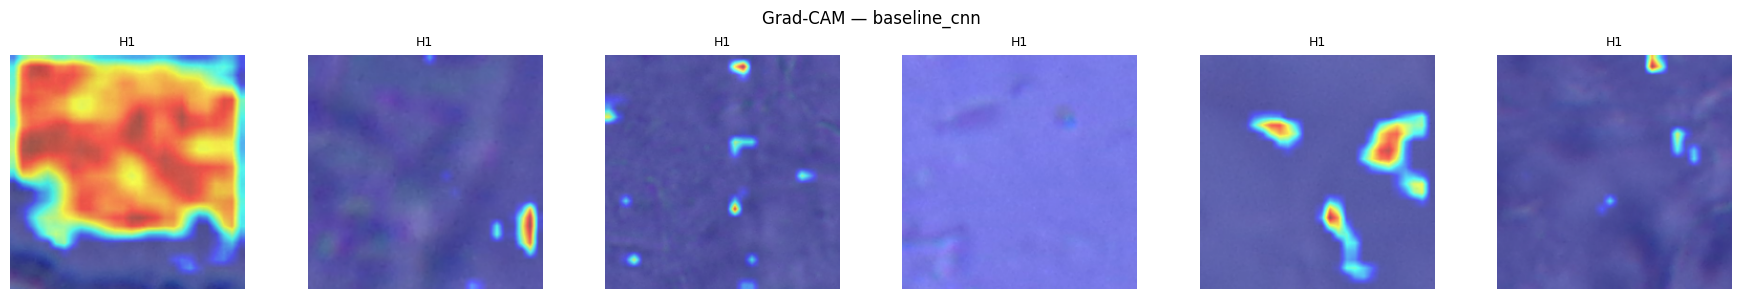

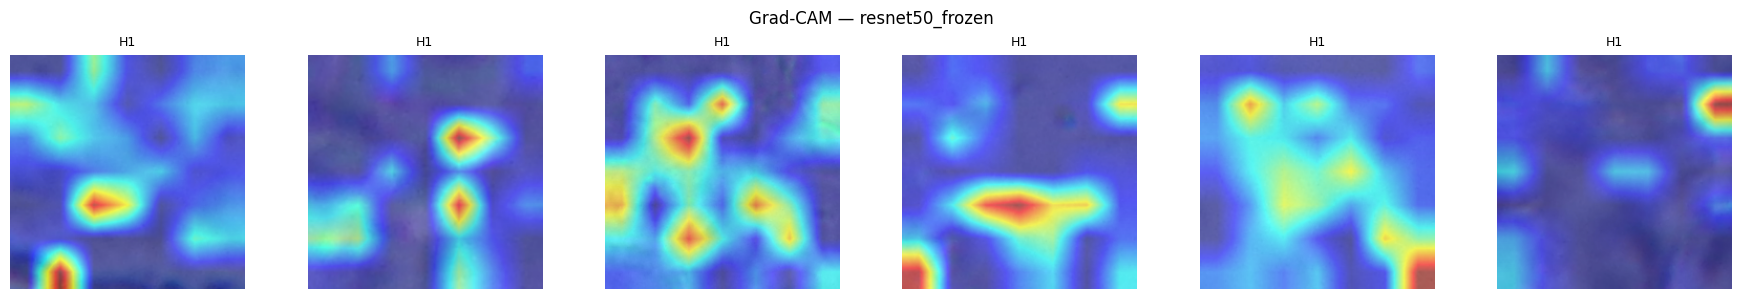

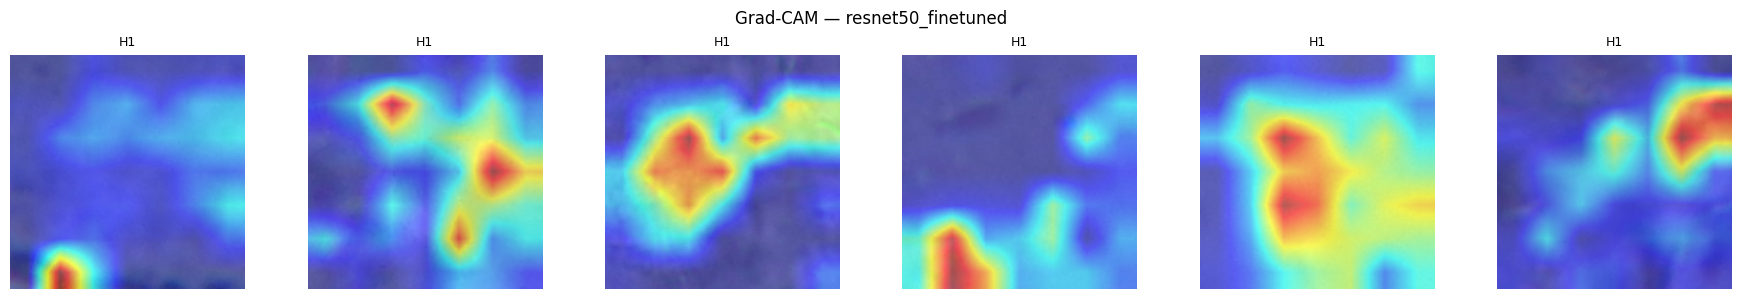

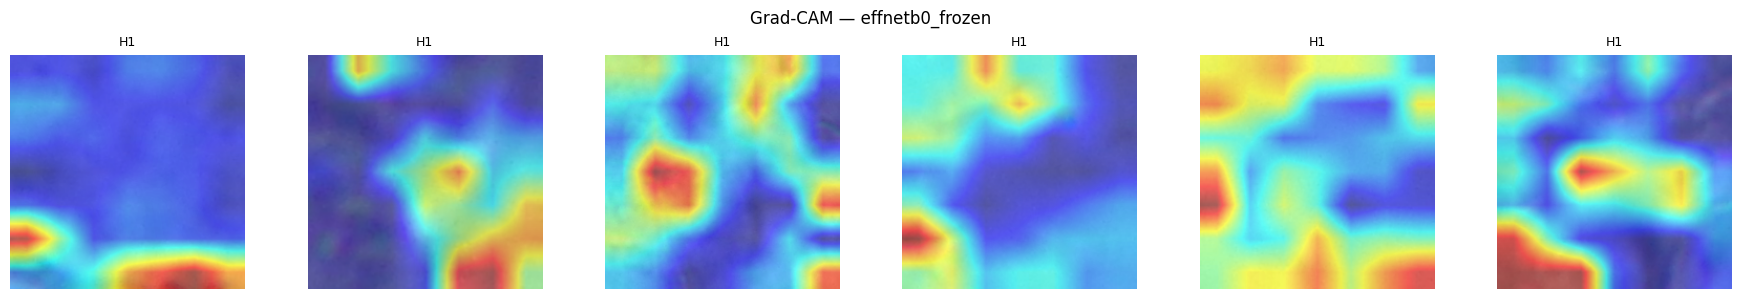

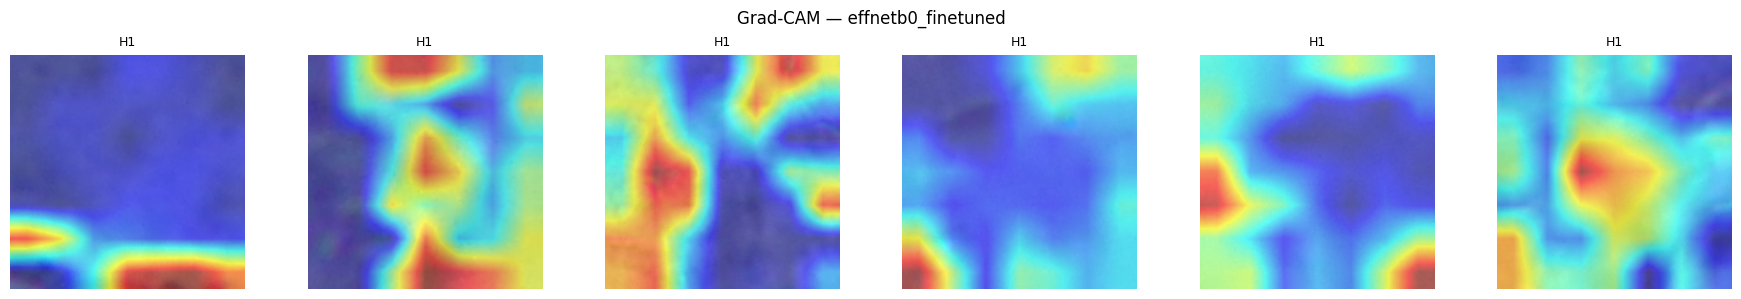

In [23]:
gradcam_target_layer = {
    "baseline_cnn":        lambda m: m.features[-1][0],
    "resnet50_frozen":     lambda m: m.layer4[-1],
    "resnet50_finetuned":  lambda m: m.layer4[-1],
    "effnetb0_frozen":     lambda m: m.features[-1],
    "effnetb0_finetuned":  lambda m: m.features[-1],
}

for tag, model in trained_models.items():
    run_gradcam(model, gradcam_target_layer[tag](model), test_loader, tag=tag)


## Save everything before the runtime disconnects

In [24]:
import glob, zipfile

with zipfile.ZipFile("fungai_outputs.zip", "w") as zf:
    for f in glob.glob("cm_*.png") + glob.glob("gradcam_*.png") + glob.glob("*.csv"):
        zf.write(f)

from google.colab import files
files.download("fungai_outputs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Notes for the write-up

- **Training time**: capture `time.time()` deltas per configuration (already timed per-epoch above)
  and report total wall-clock per model — the proposal promises this comparison.
- **Reproducibility**: seed=42 is set for `random`, `numpy`, and `torch`; record exact package
  versions with `!pip freeze > requirements.txt` before you finish and commit that to the repo.
- **Statistical significance**: if time allows, repeat the best configuration 3x with different
  seeds and report mean ± std for macro-F1 — the paper rubric asks for this.
- Save all `cm_*.png`, `gradcam_*.png`, and `results_summary.csv` — these are your slide and
  paper figures.
